# Deconvolving Spherical (HEALPix) Maps to Recover Small-Scale Power

When we paint a 3-D particle field onto the curved sky with
[`jaxpm/spherical.py`](../jaxpm/spherical.py), the assignment kernel **smears** the density field,
suppressing small-scale (high-$\ell$) angular power. Because the map lives on a sphere we undo this
in **spherical harmonics**, dividing out the smearing *per multipole* $\ell$:

$$ C_\ell^{\mathrm{true}} = \frac{C_\ell^{\mathrm{meas}} - N_\ell}{W_\ell^{2}}, \qquad
   W_\ell = p_\ell \times (\text{kernel window}). $$

$W_\ell$ combines the HEALPix **pixel window** $p_\ell$ with the painter's kernel window:

| Painter | Kernel | Total window $W_\ell$ |
|---|---|---|
| **NGP** | nearest pixel | $p_\ell$ (exact) |
| **Bilinear** | 4 nearest pixels | $p_\ell \times w_\ell^{\mathrm{bilinear}}$ (no closed form → measure it) |
| **RBF** | Gaussian over a 9-pixel stencil | $p_\ell \times B_\ell(\theta_{\rm fwhm})$ |

**Thesis.** Map-level deconvolution recovers small-scale power, but **two distinct things limit
it**, and this notebook separates them cleanly:

1. **Shot noise** ($N_\ell = 4\pi/N$ from discrete particles) is amplified by $1/W_\ell^2$ → a noise
   wall. It shrinks only with *more particles* (§10 at $64^3$ → §11 at $512^3$).
2. **Window-model error.** A kernel *wider than the pixel* spills outside the 9-pixel stencil, so the
   analytic $B_\ell$ over-predicts the smoothing and the deconvolution **over-corrects** (§12).

The fix for (2) is to **match the kernel to the pixel scale**: we therefore use a **FWHM = 1 pixel**
RBF kernel as the sensible default. Painting is JAX; the harmonic transforms (`map2alm`, `anafast`,
`pixwin`, `gauss_beam`, `synfast`) are `healpy`, in double precision.

## 1 · Setup

CPU execution (avoids GPU contention; healpy does the harmonic transforms in double precision).

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import jax
import jax.numpy as jnp
import healpy as hp
import matplotlib.pyplot as plt

from jaxpm.spherical import paint_particles_spherical
from jaxpm.pm import linear_field, lpt
import jax_cosmo as jc

np.random.seed(42)
key = jax.random.PRNGKey(42)
plt.rcParams.update({"figure.figsize": (13, 5), "font.size": 12})
OK = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9"]  # Okabe-Ito
print("JAX backend:", jax.default_backend(), "| healpy", hp.__version__)

JAX backend: cpu | healpy 1.19.0


## 2 · Simulation geometry

A $64^3$ particle cube in a $1\,h^{-1}{\rm Gpc}$ box. The observer sits at the **box centre** with a
shell $R_{\max} < L/2$, so the shell is fully enclosed and the map is **full-sky** (no mask). The
Poisson shot-noise floor of the overdensity map is $N_\ell = 4\pi/N_{\rm shell}$ — set by the
*number* of particles, **independent of nside**.

In [2]:
box_size   = (1000.0, 1000.0, 1000.0)   # Mpc/h
mesh_shape = (64, 64, 64)                # particle cube -> positions (64,64,64,3)
nside      = 64
omega_c, sigma8 = 0.25, 0.8
cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)

observer_position = np.array([500.0, 500.0, 500.0])  # box centre -> full sky
R_min, R_max = 150.0, 450.0                          # R_max < L/2 = 500
scale_factor = float(jc.background.a_of_chi(cosmo, (R_min + R_max) / 2).squeeze())

npix         = hp.nside2npix(nside)
resol_arcmin = hp.nside2resol(nside, arcmin=True)    # one pixel, in arcmin
LMAX         = 3 * nside
ell          = np.arange(LMAX + 1)
print(f"nside={nside}  npix={npix:,}  pixel scale={resol_arcmin:.1f}'  LMAX={LMAX}")
print(f"shell [{R_min:.0f}, {R_max:.0f}] Mpc/h  ->  a_center={scale_factor:.3f}")

nside=64  npix=49,152  pixel scale=55.0'  LMAX=192
shell [150, 450] Mpc/h  ->  a_center=0.907


## 3 · Generate the particle field (LPT)

First-order LPT: build $P(k)$, draw a Gaussian field, displace a grid. Parametrised by `mesh` so we can reuse it at $512^3$ in §11.

In [3]:
def generate_lpt_particles(omega_c, sigma8, scale_factor, mesh):
    k  = jnp.logspace(-4, 1, 128)
    pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
    pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)
    ic = linear_field(mesh, box_size, pk_fn, seed=key)
    grid = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh], indexing="ij"), axis=-1)
    dx, _, _ = lpt(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), ic, a=scale_factor, order=1)
    return grid + dx

positions = generate_lpt_particles(omega_c, sigma8, scale_factor, mesh_shape)

pos_phys = positions * jnp.array(box_size) / jnp.array(mesh_shape)
r = jnp.sqrt(jnp.sum((pos_phys - observer_position) ** 2, axis=-1))
N_shell = int(jnp.sum((r >= R_min) & (r <= R_max)))
N_white = 4 * np.pi / N_shell
print(f"positions shape: {positions.shape}")
print(f"particles in shell: {N_shell:,}  mean occupancy {N_shell/npix:.2f}/pixel")
print(f"shot-noise floor  N_l = 4pi/N = {N_white:.3e}")

positions shape: (64, 64, 64, 3)
particles in shell: 96,317  mean occupancy 1.96/pixel
shot-noise floor  N_l = 4pi/N = 1.305e-04


## 4 · Paint the field three ways — **1-pixel RBF kernel**

Same particles, three kernels. For RBF we set **FWHM = 1 pixel** (`kernel_width_arcmin = resol`):
a $\sigma\!\approx\!0.42$-pixel Gaussian sits almost entirely inside the 9-pixel stencil, so its
window is faithfully the analytic $B_\ell$ (we confirm this in §8, and show in §12 what goes wrong
for a *wide* kernel). Convert each density map to overdensity $\delta=\rho/\bar\rho-1$.

In [4]:
FWHM_arcmin = 1.0 * resol_arcmin          # 1-pixel kernel (matched to the grid)
common = dict(nside=nside, observer_position=observer_position, R_min=R_min, R_max=R_max,
              box_size=box_size, mesh_shape=mesh_shape)

raw = {
    "NGP":      np.array(paint_particles_spherical(positions, method="ngp", **common)),
    "Bilinear": np.array(paint_particles_spherical(positions, method="bilinear", **common)),
    "RBF":      np.array(paint_particles_spherical(positions, method="RBF_NEIGHBOR",
                          kernel_width_arcmin=FWHM_arcmin, smoothing_interpretation="fwhm", **common)),
}
def overdensity(m):
    mu = m.mean()
    return (m - mu) / mu if mu > 0 else m * 0.0
delta = {k: overdensity(v) for k, v in raw.items()}
for k, v in delta.items():
    print(f"{k:9s}: delta std = {v.std():.3f}")
print(f"RBF Gaussian FWHM = {FWHM_arcmin:.0f}' = {FWHM_arcmin/resol_arcmin:.1f} pixel")

NGP      : delta std = 0.681
Bilinear : delta std = 0.434
RBF      : delta std = 0.424
RBF Gaussian FWHM = 55' = 1.0 pixel


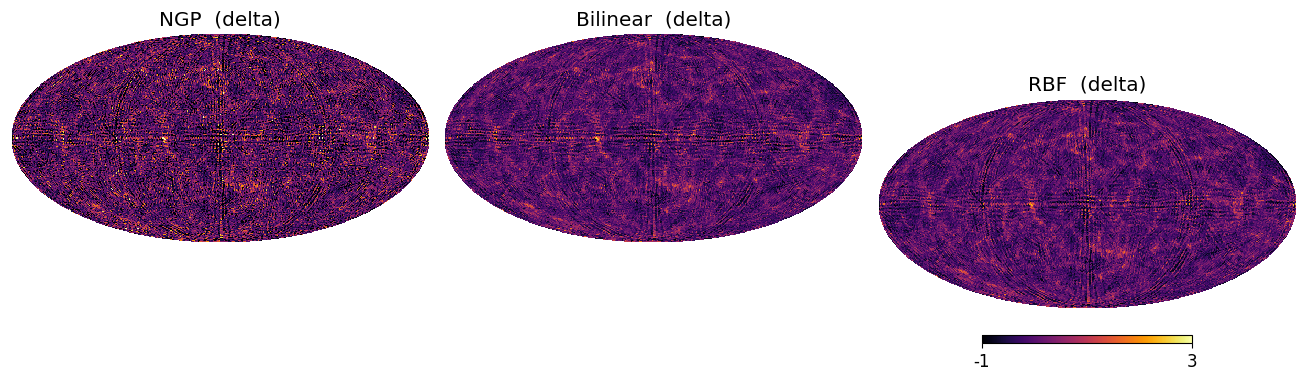

In [5]:
for i, k in enumerate(["NGP", "Bilinear", "RBF"]):
    hp.mollview(delta[k], title=f"{k}  (delta)", sub=(1, 3, i + 1),
                min=-1, max=3, cmap="inferno", cbar=(i == 2))
plt.show()

## 5 · The smearing in harmonic space

`anafast` gives each map's raw $C_\ell$. With a 1-pixel kernel the RBF damping is mild; the three
kernels agree at low $\ell$ and separate only at high $\ell$, where NGP (white shot noise) sits
highest. The dotted line is the Poisson floor $4\pi/N$ — note how quickly the $64^3$ spectra meet
it (around $\ell\sim40$): this map is **shot-noise limited**.

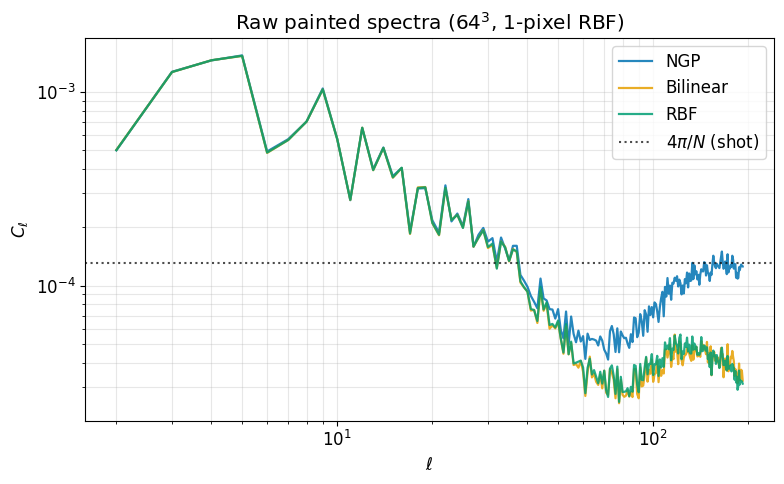

In [6]:
cl_raw = {k: hp.anafast(v, lmax=LMAX) for k, v in delta.items()}
sl = slice(2, None)
plt.figure(figsize=(8, 5))
for i, k in enumerate(["NGP", "Bilinear", "RBF"]):
    plt.loglog(ell[sl], cl_raw[k][sl], color=OK[i], lw=1.6, alpha=.85, label=k)
plt.axhline(N_white, ls=":", c="k", alpha=.7, label=r"$4\pi/N$ (shot)")
plt.xlabel(r"$\ell$"); plt.ylabel(r"$C_\ell$"); plt.title("Raw painted spectra ($64^3$, 1-pixel RBF)")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

## 6 · The deconvolution operator — at the map / $a_{\ell m}$ level

A **per-mode linear filter applied to the map** through its harmonic coefficients:

1. $a_{\ell m} = \texttt{map2alm}(m)$ → 2. $a_{\ell m} \leftarrow a_{\ell m}/W_\ell$ (with a hard
$\ell_{\max}$ cut) via `almxfl` → 3. $m_{\rm deconv} = \texttt{alm2map}(a_{\ell m})$.

We then re-measure $C_\ell$. **Window deconvolution is a map-level (per-mode) operation, but
shot-noise subtraction is a power-level ($C_\ell$) operation** — you cannot subtract a noise
*realisation* from a single map, only its expected *power*; that is why the wall ($N_\ell/W_\ell^2$)
appears in the deconvolved map's spectrum.

In [7]:
def deconvolve_map(m, W, lmax, lcut=None):
    # Map/alm-level window deconvolution: map2alm -> divide by W_l -> alm2map
    alm = hp.map2alm(np.asarray(m), lmax=lmax)
    inv = np.zeros_like(W); good = W > 1e-8; inv[good] = 1.0 / W[good]
    if lcut is not None:
        inv[lcut + 1:] = 0.0                      # truncate at the safe ell_max
    return hp.alm2map(hp.almxfl(alm, inv), nside=hp.npix2nside(m.size), lmax=lmax)

def bin_ell(y, ell, nbins=22, lmin=2, lmax=LMAX):
    edges = np.unique(np.geomspace(lmin, lmax, nbins + 1).astype(int))
    lb, yb = [], []
    for a, b in zip(edges[:-1], edges[1:]):
        msk = (ell >= a) & (ell < b)
        if msk.any(): lb.append(ell[msk].mean()); yb.append(np.mean(y[msk]))
    return np.array(lb), np.array(yb)

## 7 · Controlled validation — known beam, ground truth

Validate the operator where the answer is known. `synfast` a band-limited field **without** the
pixel window, smooth it with a **known strong** Gaussian beam (here 2.5 pixels, to make the test
bite), then deconvolve by **that same beam only**.

> **Window-match rule:** deconvolve by *exactly* the window applied. The synthetic field is not
> binned onto pixels → no $p_\ell$; dividing by `pixwin` here would inject a spurious $1/p_\ell^2$.
> (Painted maps *are* binned, so for them $W_\ell$ *does* include $p_\ell$.)

Recovery is essentially perfect — proof that the map-level operator restores small-scale power when
the window is known and there is no noise.

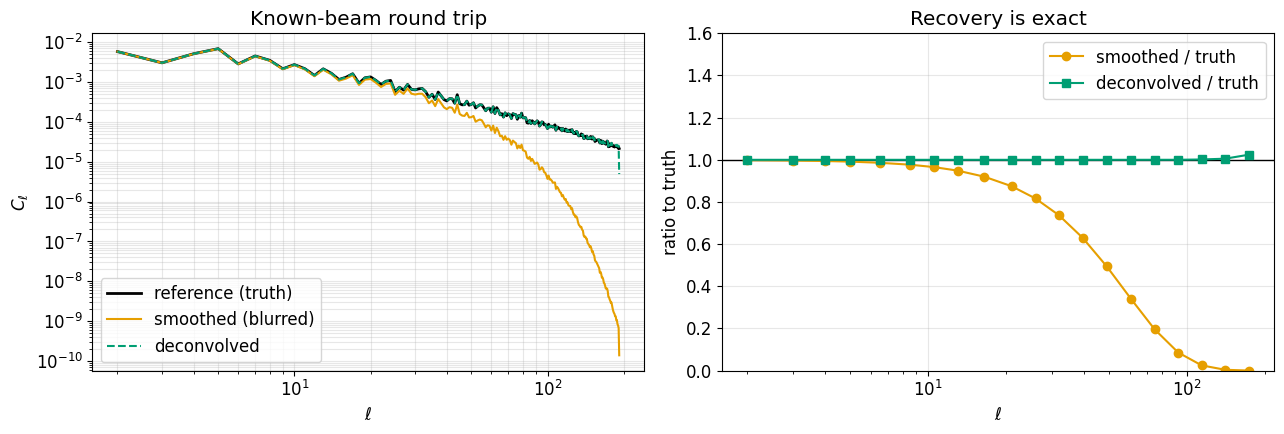

decon/ref at l=30,60,100,128: [1.0, 1.0, 0.999, 1.013]


In [8]:
FWHM_test = 2.5 * resol_arcmin
gauss_test = hp.gauss_beam(np.deg2rad(FWHM_test / 60.0), lmax=LMAX)
cl_in  = 1.0 / (ell + 10.0) ** 2
m_ref  = hp.synfast(cl_in, nside, lmax=LMAX, pixwin=False)
m_blur = hp.smoothing(m_ref, fwhm=np.deg2rad(FWHM_test / 60.0))
m_rec  = deconvolve_map(m_blur, gauss_test, LMAX)
cl_ref, cl_blur, cl_rec = (hp.anafast(x, lmax=LMAX) for x in (m_ref, m_blur, m_rec))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].loglog(ell[sl], cl_ref[sl],  "k-", lw=2, label="reference (truth)")
ax[0].loglog(ell[sl], cl_blur[sl], color=OK[1], label="smoothed (blurred)")
ax[0].loglog(ell[sl], cl_rec[sl], "--", color=OK[2], label="deconvolved")
ax[0].set(xlabel=r"$\ell$", ylabel=r"$C_\ell$", title="Known-beam round trip")
ax[0].legend(); ax[0].grid(alpha=.3, which="both")
ax[1].axhline(1, c="k", lw=1)
ax[1].semilogx(*bin_ell(cl_blur / cl_ref, ell), "o-", color=OK[1], label="smoothed / truth")
ax[1].semilogx(*bin_ell(cl_rec / cl_ref, ell), "s-", color=OK[2], label="deconvolved / truth")
ax[1].set(xlabel=r"$\ell$", ylabel="ratio to truth", ylim=(0, 1.6), title="Recovery is exact")
ax[1].legend(); ax[1].grid(alpha=.3); plt.tight_layout(); plt.show()
print("decon/ref at l=30,60,100,128:", [round(float(cl_rec[l]/cl_ref[l]), 3) for l in (30,60,100,128)])

## 8 · Window functions — the 1-pixel kernel is well-modelled

- **NGP:** $W_\ell = p_\ell$ (`hp.pixwin`).
- **RBF (analytic):** $W_\ell = p_\ell B_\ell$ from the known FWHM (`hp.gauss_beam`).
- **Empirical:** with NGP as a $p_\ell$-only reference, $W_\ell^{\rm emp}=p_\ell\sqrt{C_\ell^{\rm method}/C_\ell^{\rm NGP}}$.

**Finding (1-pixel kernel).** The empirical RBF window sits essentially **on top of** the analytic
$p_\ell B_\ell$ — the narrow Gaussian fits the 9-pixel stencil, so the analytic model is accurate
and the analytic deconvolution will recover cleanly. (§12 shows this breaks for a *wide* kernel.)

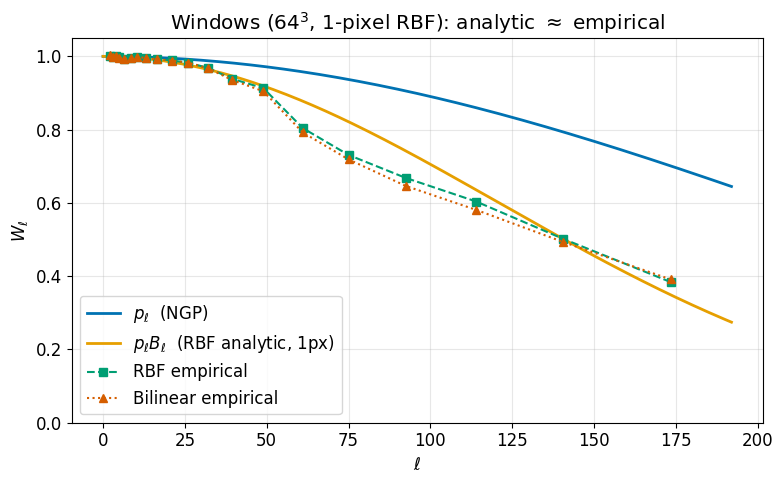

In [9]:
gauss = hp.gauss_beam(np.deg2rad(FWHM_arcmin / 60.0), lmax=LMAX)   # the 1-pixel painting beam
pix = hp.pixwin(nside, lmax=LMAX)
W = {"NGP": pix, "RBF_analytic": pix * gauss}
with np.errstate(divide="ignore", invalid="ignore"):
    W["RBF_emp"]      = pix * np.sqrt(np.clip(cl_raw["RBF"]      / cl_raw["NGP"], 0, None))
    W["Bilinear_emp"] = pix * np.sqrt(np.clip(cl_raw["Bilinear"] / cl_raw["NGP"], 0, None))

plt.figure(figsize=(8, 5))
plt.plot(ell, W["NGP"],          color=OK[0], lw=2, label=r"$p_\ell$  (NGP)")
plt.plot(ell, W["RBF_analytic"], color=OK[1], lw=2, label=r"$p_\ell B_\ell$  (RBF analytic, 1px)")
plt.plot(*bin_ell(W["RBF_emp"], ell), "s--", color=OK[2], label="RBF empirical")
plt.plot(*bin_ell(W["Bilinear_emp"], ell), "^:", color=OK[3], label="Bilinear empirical")
plt.xlabel(r"$\ell$"); plt.ylabel(r"$W_\ell$"); plt.ylim(0, 1.05)
plt.title("Windows ($64^3$, 1-pixel RBF): analytic $\\approx$ empirical")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 9 · Recovery at $64^3$ — clean, until shot noise takes over

Truth proxy = NGP deconvolved by $p_\ell$. Deconvolving the 1-pixel RBF map by its analytic
$p_\ell B_\ell$ **restores the suppressed power with no over-shoot** (the window is accurate). The
ratio sits at 1 until $\ell\sim40$, beyond which the $64^3$ map is shot-noise dominated and there is
no signal left to recover — only amplified noise (§10).

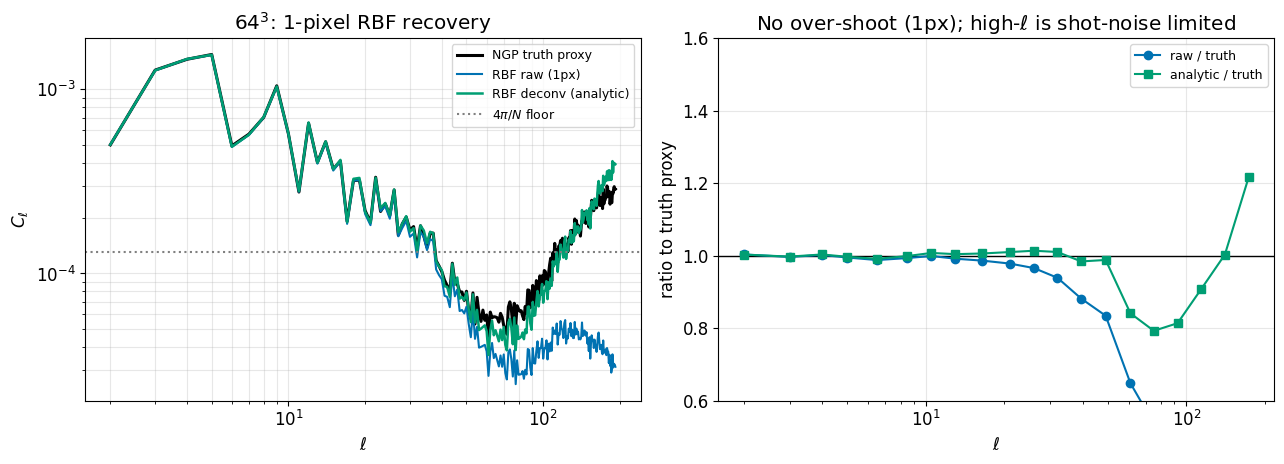

In [10]:
truth   = hp.anafast(deconvolve_map(delta["NGP"], W["NGP"], LMAX), lmax=LMAX)
rbf_an  = hp.anafast(deconvolve_map(delta["RBF"], W["RBF_analytic"], LMAX), lmax=LMAX)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].loglog(ell[sl], truth[sl],         "k-",  lw=2.2, label="NGP truth proxy")
ax[0].loglog(ell[sl], cl_raw["RBF"][sl], color=OK[0], label="RBF raw (1px)")
ax[0].loglog(ell[sl], rbf_an[sl],        color=OK[2], lw=1.8, label="RBF deconv (analytic)")
ax[0].axhline(N_white, ls=":", c="grey", label=r"$4\pi/N$ floor")
ax[0].set(xlabel=r"$\ell$", ylabel=r"$C_\ell$", title="$64^3$: 1-pixel RBF recovery")
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3, which="both")
ax[1].axhline(1, c="k", lw=1)
ax[1].semilogx(*bin_ell(cl_raw["RBF"] / truth, ell), "o-", color=OK[0], label="raw / truth")
ax[1].semilogx(*bin_ell(rbf_an / truth, ell),        "s-", color=OK[2], label="analytic / truth")
ax[1].set(xlabel=r"$\ell$", ylabel="ratio to truth proxy", ylim=(0.6, 1.6),
          title="No over-shoot (1px); high-$\\ell$ is shot-noise limited")
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3); plt.tight_layout(); plt.show()

## 10 · The shot-noise wall at $64^3$

NGP drops each particle in one pixel, so its shot noise is **white** ($4\pi/N$, flat). Deconvolving
gives $C_\ell^{\rm true} + (4\pi/N)/p_\ell^2$ — and at $64^3$ the field has essentially no signal
above $\ell\sim40$, so the truth proxy itself **is** the amplified white floor at high $\ell$ (the
dotted curve traces it). This is the wall: $1/W_\ell^2$ blows up the irreducible Poisson noise.
You could truncate at $\ell_{\max}$, but the real cure is **more particles** — next section.

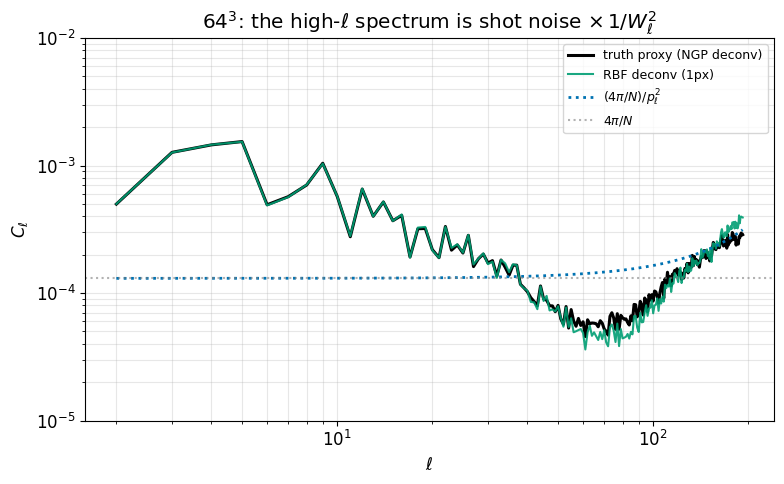

In [11]:
rbf_dec = hp.anafast(deconvolve_map(delta["RBF"], W["RBF_analytic"], LMAX), lmax=LMAX)
plt.figure(figsize=(8, 5))
plt.loglog(ell[sl], truth[sl], "k-", lw=2.2, label="truth proxy (NGP deconv)")
plt.loglog(ell[sl], rbf_dec[sl], color=OK[2], lw=1.5, alpha=.9, label="RBF deconv (1px)")
plt.loglog(ell[sl], (N_white / W["NGP"] ** 2)[sl], ":", color=OK[0], lw=2, label=r"$(4\pi/N)/p_\ell^2$")
plt.axhline(N_white, ls=":", c="grey", alpha=.6, label=r"$4\pi/N$")
plt.xlabel(r"$\ell$"); plt.ylabel(r"$C_\ell$"); plt.ylim(1e-5, 1e-2)
plt.title(r"$64^3$: the high-$\ell$ spectrum is shot noise $\times\,1/W_\ell^2$")
plt.legend(fontsize=9); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

## 11 · Kill the shot noise — re-run at $512^3$ (chunked painting)

The floor $4\pi/N$ depends only on the particle *count*, so we crank it down with a $512^3$ cube
(~50M particles in the shell → ~16/pixel → floor **500× lower**). At nside 512 a single RBF paint of
134M particles would need ~40 GB for one intermediate, so we **chunk**: $512^3 = 8\times256^3$
exactly, paint each chunk and **sum the density maps** (scatter-add is associative → identical to
painting all at once). This is the only new machinery needed.

In [12]:
nside512 = 512
npix512  = hp.nside2npix(nside512)
resol512 = hp.nside2resol(nside512, arcmin=True)
LMAX512  = 2 * nside512
ell512   = np.arange(LMAX512 + 1); sl5 = slice(2, None)
mesh512  = (512, 512, 512)

pos512 = generate_lpt_particles(omega_c, sigma8, scale_factor, mesh512).reshape(-1, 3)
pp = pos512 * jnp.array(box_size) / jnp.array(mesh512)
r512 = jnp.sqrt(jnp.sum((pp - observer_position) ** 2, axis=-1))
N_shell512 = int(jnp.sum((r512 >= R_min) & (r512 <= R_max))); del pp, r512
N_white512 = 4 * np.pi / N_shell512

def paint_chunked(method, nchunks=8, **extra):
    cs = pos512.shape[0] // nchunks
    acc = np.zeros(npix512, np.float64)
    for i in range(nchunks):
        acc += np.asarray(paint_particles_spherical(
            pos512[i*cs:(i+1)*cs], method=method, nside=nside512,
            observer_position=observer_position, R_min=R_min, R_max=R_max,
            box_size=box_size, mesh_shape=mesh512, **extra)).astype(np.float64)
    return acc

print(f"512^3: N_shell={N_shell512:,}  occupancy={N_shell512/npix512:.1f}/pix")
print(f"floor 4pi/N = {N_white512:.2e}  (was {N_white:.2e} at 64^3, i.e. {N_white/N_white512:.0f}x lower)")
ngp512   = overdensity(paint_chunked("ngp"))
rbf512_1 = overdensity(paint_chunked("RBF_NEIGHBOR", kernel_width_arcmin=1.0*resol512, smoothing_interpretation="fwhm"))
rbf512_2 = overdensity(paint_chunked("RBF_NEIGHBOR", kernel_width_arcmin=2.5*resol512, smoothing_interpretation="fwhm"))
del pos512
print("painting done")

512^3: N_shell=49,615,306  occupancy=15.8/pix
floor 4pi/N = 2.53e-07  (was 1.30e-04 at 64^3, i.e. 515x lower)


painting done


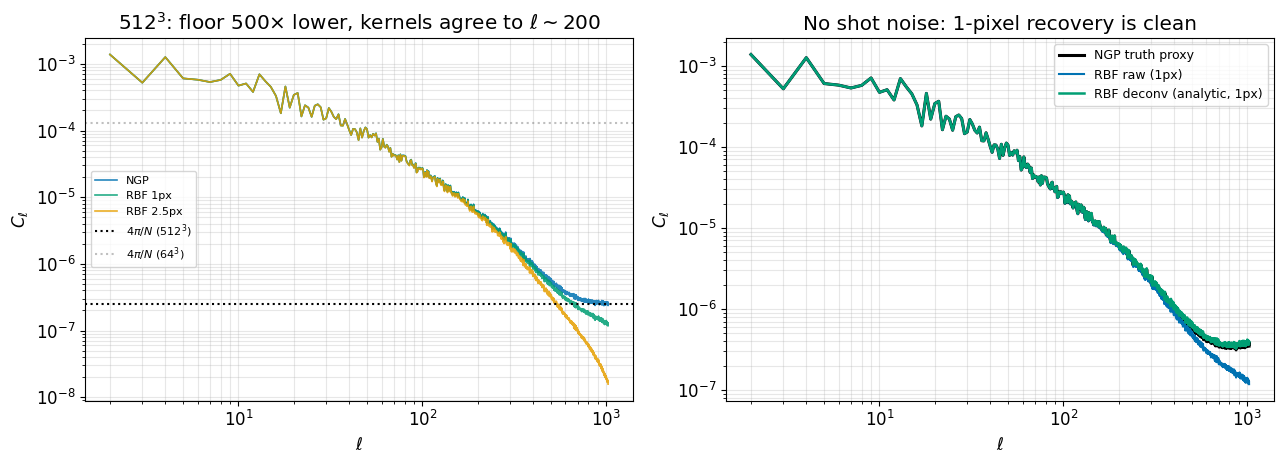

1px  analytic/truth @ l=200,400,700,900: [1.01, 1.03, 1.08, 1.02]


In [13]:
pix512    = hp.pixwin(nside512, lmax=LMAX512)
cl_ngp512 = hp.anafast(ngp512, lmax=LMAX512)
truth512  = hp.anafast(deconvolve_map(ngp512, pix512, LMAX512), lmax=LMAX512)

def rbf_curves(rbf_map, fwhm):
    gb = hp.gauss_beam(np.deg2rad(fwhm / 60.0), lmax=LMAX512)
    clm = hp.anafast(rbf_map, lmax=LMAX512)
    with np.errstate(divide="ignore", invalid="ignore"):
        Wemp = pix512 * np.sqrt(np.clip(clm / cl_ngp512, 0, None))
    return dict(cl=clm, Wan=pix512 * gb, Wemp=Wemp,
                an=hp.anafast(deconvolve_map(rbf_map, pix512 * gb, LMAX512), lmax=LMAX512),
                emp=hp.anafast(deconvolve_map(rbf_map, Wemp, LMAX512), lmax=LMAX512))
R1 = rbf_curves(rbf512_1, 1.0 * resol512)    # 1-pixel kernel
R2 = rbf_curves(rbf512_2, 2.5 * resol512)    # 2.5-pixel kernel (wide)

# Raw spectra (floor crushed) + clean 1-pixel recovery
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for nm, c, cc in [("NGP", cl_ngp512, OK[0]), ("RBF 1px", R1["cl"], OK[2]), ("RBF 2.5px", R2["cl"], OK[1])]:
    ax[0].loglog(ell512[sl5], c[sl5], color=cc, lw=1.2, alpha=.85, label=nm)
ax[0].axhline(N_white512, ls=":", c="k", label=r"$4\pi/N$ (512$^3$)")
ax[0].axhline(N_white, ls=":", c="grey", alpha=.5, label=r"$4\pi/N$ (64$^3$)")
ax[0].set(xlabel=r"$\ell$", ylabel=r"$C_\ell$", title="$512^3$: floor 500$\\times$ lower, kernels agree to $\\ell\\sim200$")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, which="both")
ax[1].loglog(ell512[sl5], truth512[sl5], "k-", lw=2.2, label="NGP truth proxy")
ax[1].loglog(ell512[sl5], R1["cl"][sl5],  color=OK[0], label="RBF raw (1px)")
ax[1].loglog(ell512[sl5], R1["an"][sl5],  color=OK[2], lw=1.8, label="RBF deconv (analytic, 1px)")
ax[1].set(xlabel=r"$\ell$", ylabel=r"$C_\ell$", title="No shot noise: 1-pixel recovery is clean")
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()
print("1px  analytic/truth @ l=200,400,700,900:", [round(float(R1['an'][l]/truth512[l]),2) for l in (200,400,700,900)])

## 12 · The punchline — kernel width sets the over-shoot

With shot noise gone, the *only* residual is the **window model**. Deconvolving by the analytic
$p_\ell B_\ell$:

- **FWHM = 1 pixel:** analytic $\approx$ empirical (the Gaussian fits the stencil) → the ratio stays
  flat at 1 across the whole range. **Clean recovery of small-scale power.**
- **FWHM = 2.5 pixel:** the kernel spills outside the 9-pixel stencil, so the real window is *higher*
  than $p_\ell B_\ell$ (it suppresses *less*). Dividing by the too-small analytic window
  **over-corrects** — a *smooth, deterministic* climb to several×, not noise.

So: **match the kernel to the pixel scale** (1-pixel → clean recovery), or for a wider kernel use
the **measured (empirical) window** — the analytic Gaussian is trustworthy only where its over-shoot
is still small.

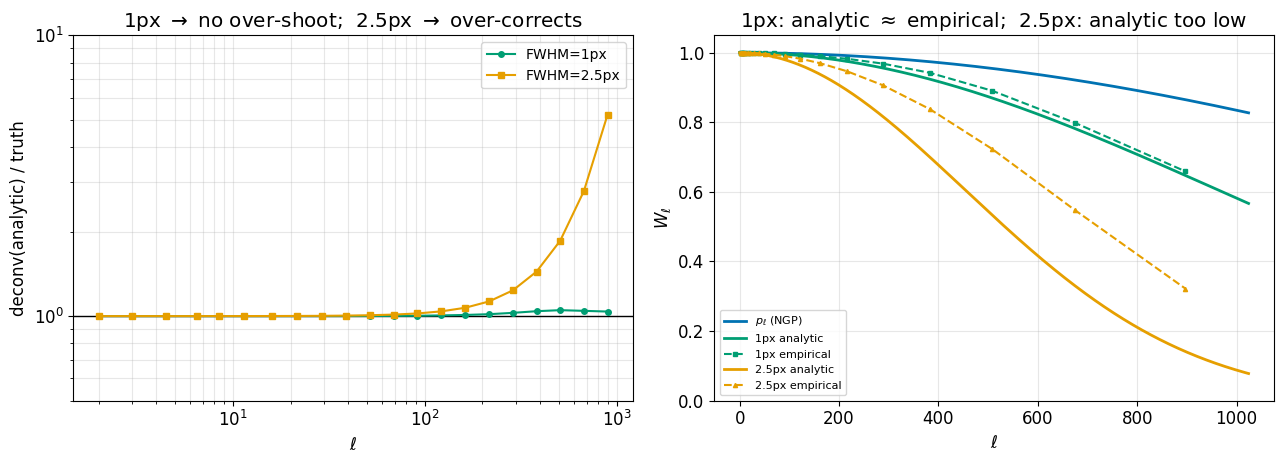

2.5px analytic/truth @ l=200,400,700,900: [1.11, 1.47, 3.02, 5.04]


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].axhline(1, c="k", lw=1)
ax[0].loglog(*bin_ell(R1["an"]/truth512, ell512, lmax=LMAX512), "o-", color=OK[2], ms=4, label="FWHM=1px")
ax[0].loglog(*bin_ell(R2["an"]/truth512, ell512, lmax=LMAX512), "s-", color=OK[1], ms=4, label="FWHM=2.5px")
ax[0].set(xlabel=r"$\ell$", ylabel="deconv(analytic) / truth", ylim=(0.5, 10),
          title="1px $\\to$ no over-shoot;  2.5px $\\to$ over-corrects")
ax[0].legend(fontsize=10); ax[0].grid(alpha=.3, which="both")
ax[1].plot(ell512, pix512, color=OK[0], lw=2, label=r"$p_\ell$ (NGP)")
ax[1].plot(ell512, R1["Wan"], color=OK[2], lw=2, label="1px analytic")
ax[1].plot(*bin_ell(R1["Wemp"], ell512, lmax=LMAX512), "s--", color=OK[2], ms=3, label="1px empirical")
ax[1].plot(ell512, R2["Wan"], color=OK[1], lw=2, label="2.5px analytic")
ax[1].plot(*bin_ell(R2["Wemp"], ell512, lmax=LMAX512), "^--", color=OK[1], ms=3, label="2.5px empirical")
ax[1].set(xlabel=r"$\ell$", ylabel=r"$W_\ell$", ylim=(0, 1.05),
          title="1px: analytic $\\approx$ empirical;  2.5px: analytic too low")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3); plt.tight_layout(); plt.show()
print("2.5px analytic/truth @ l=200,400,700,900:", [round(float(R2['an'][l]/truth512[l]),2) for l in (200,400,700,900)])

**Fixing the wide kernel — not by truncating at $W\!\approx\!0.1$.** The over-shoot is a
deterministic *bias*, not a $W\to0$ noise wall: it is already $>$10% by $\ell\sim200$, long before
$W_\ell$ reaches 0.1 (at $\ell\sim970$), so a $W\!=\!0.1$ cut would keep almost all of it. The
analytic window is only trustworthy at low $\ell$; the **measured (empirical) window** — the actual
stencil window, self-calibrated against NGP — is the correct window. It equals the truth proxy *by
construction*, so it removes the deterministic bias in the **signal** regime; but past the
signal\,/\,$4\pi/N$ crossing (a few hundred $\ell$, §11) both it and the truth proxy track the
amplified **shot floor**, not signal — shown by the dotted $(4\pi/N)/p_\ell^2$ curve below.

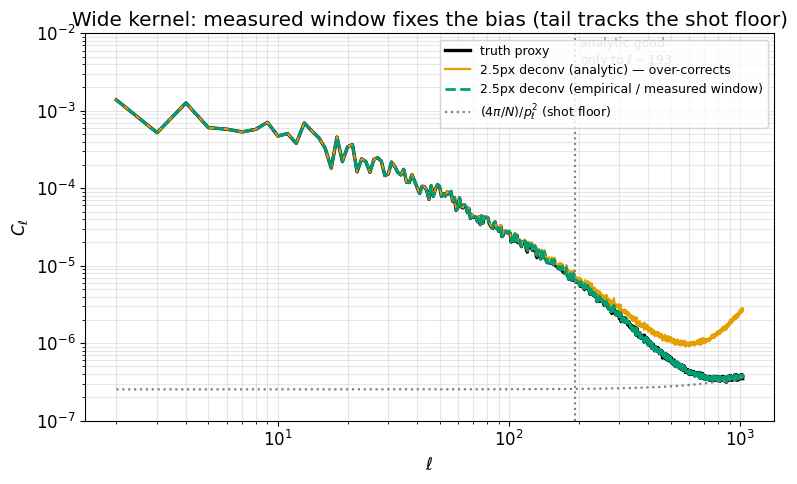

2.5px analytic window trustworthy only to l ~ 193  (W=0.1 is way out at l~972)


In [15]:
ratio2 = R2["an"] / truth512
lmax_an = int(ell512[(ell512 >= 50) & (ratio2 > 1.1)][0])   # where analytic over-shoot first exceeds 10%
plt.figure(figsize=(8, 5))
plt.loglog(ell512[sl5], truth512[sl5], "k-", lw=2.4, label="truth proxy")
plt.loglog(ell512[sl5], R2["an"][sl5],  color=OK[1], lw=1.6, label="2.5px deconv (analytic) — over-corrects")
plt.loglog(ell512[sl5], R2["emp"][sl5], "--", color=OK[2], lw=2.0, label="2.5px deconv (empirical / measured window)")
plt.loglog(ell512[sl5], (N_white512 / pix512 ** 2)[sl5], ":", color="0.5", lw=1.6, label=r"$(4\pi/N)/p_\ell^2$ (shot floor)")
plt.axvline(lmax_an, c="grey", ls=":")
plt.text(lmax_an * 1.05, 4e-3, f"analytic good\nonly to $\\ell\\sim{lmax_an}$", color="grey", fontsize=9)
plt.xlabel(r"$\ell$"); plt.ylabel(r"$C_\ell$"); plt.ylim(1e-7, 1e-2)
plt.title(r"Wide kernel: measured window fixes the bias (tail tracks the shot floor)")
plt.legend(fontsize=9); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()
print(f"2.5px analytic window trustworthy only to l ~ {lmax_an}  (W=0.1 is way out at l~972)")

## 13 · Summary

Map-level deconvolution (`map2alm` → divide $a_{\ell m}$ by $W_\ell$ → `alm2map`) recovers
small-scale power — read off at the $C_\ell$ level. **Two independent limits**, separated here:

| Limit | Symptom | Cause | Fix |
|---|---|---|---|
| **Shot noise** | high-$\ell$ wall, *noisy* | white $4\pi/N$ amplified by $1/W_\ell^2$ | **more particles** ($64^3\!\to\!512^3$ drops the floor 500×) |
| **Window model** | high-$\ell$ over-shoot, *smooth* | wide kernel spills the 9-pixel stencil; analytic $B_\ell$ over-predicts smoothing | **match kernel to pixel** (FWHM=1px), or use the **empirical** window (analytic reliable only at low $\ell$) |

**Takeaways**

1. The operator is **exact** when the window is known and there is signal (controlled test, §7).
2. A **1-pixel** RBF kernel is faithfully described by `pixwin × gauss_beam` (§8) and recovers
   small-scale power with **no over-shoot** (§9, §11–12).
3. Discrete-particle **shot noise is irreducible** ($4\pi/N$, independent of nside); only more
   particles — or painting a continuous field — lowers it (§10–11).
4. A **wide kernel over-corrects** because the analytic Gaussian mis-models the stencil (§12): a
   *deterministic* error, distinct from shot noise, and fixable with the measured window.